In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
import time
import random

from sklearn import model_selection
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge

In [85]:
df = pd.read_csv('heart.csv')

# Drops 'thal' column
df = df.drop(columns=['thal'])
# Count rows before filtering
rows_before = len(df['ca'])
# Filter rows where 'ca' is 0, 1, 2, or 3
df_filtered = df[df['ca'].isin([0, 1, 2, 3])]
# Count rows after filtering
rows_after = len(df_filtered)
# Print number of rows dropped
print('Rows dropped:', rows_before - rows_after)

df = df_filtered
print(df.count())


Rows dropped: 5
age         298
sex         298
cp          298
trestbps    298
chol        298
fbs         298
restecg     298
thalach     298
exang       298
oldpeak     298
slope       298
ca          298
target      298
dtype: int64


In [86]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,1


### Outlier Detection & Extreme Values

Box Plots for Continous variables: These continuous variables are most likely to have outliers. Box plots clearly show outliers as points beyond the whiskers.

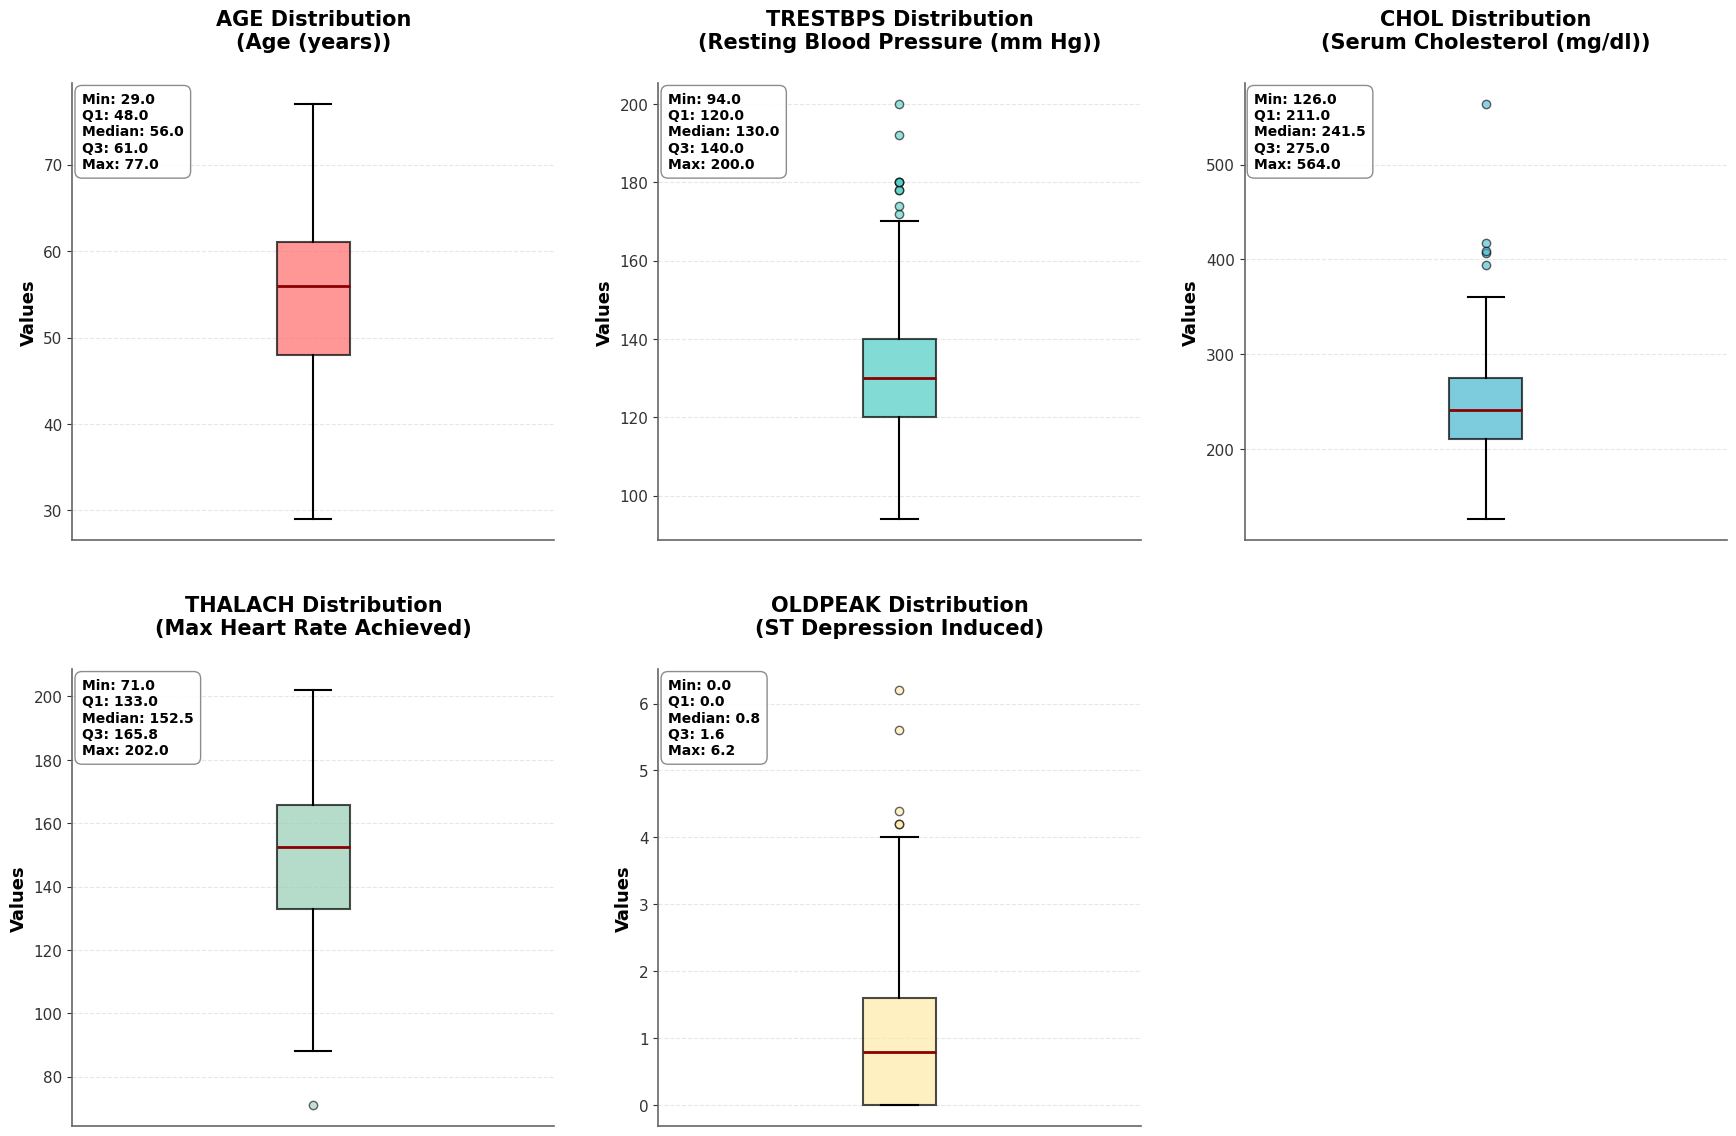

In [87]:
# Continuous variables
continuous_vars = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Variable descriptions for better interpretation
var_descriptions = {
    'age': 'Age (years)',
    'trestbps': 'Resting Blood Pressure (mm Hg)',
    'chol': 'Serum Cholesterol (mg/dl)',
    'thalach': 'Max Heart Rate Achieved',
    'oldpeak': 'ST Depression Induced'
}

# Color palette (matching previous plots)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']

# Calculate layout
n_vars = len(continuous_vars)
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols

# Create subplots with proper spacing
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
axes = axes.flatten()

for i, var in enumerate(continuous_vars):
    if var in df.columns and i < len(axes):
        
        bp = axes[i].boxplot(df[var], 
                            patch_artist=True,
                            boxprops=dict(facecolor=colors[i % len(colors)], 
                                        alpha=0.7,
                                        edgecolor='black',
                                        linewidth=1.5),
                            medianprops=dict(color='darkred', linewidth=2),
                            whiskerprops=dict(color='black', linewidth=1.5),
                            capprops=dict(color='black', linewidth=1.5),
                            flierprops=dict(marker='o', 
                                          markerfacecolor=colors[i % len(colors)], 
                                          markersize=6, 
                                          alpha=0.6,
                                          markeredgecolor='black'))
        
        # Sets title and description
        title = f'{var.upper()} Distribution'
        if var in var_descriptions:
            title += f'\n({var_descriptions[var]})'
        
        axes[i].set_title(title, fontsize=15, fontweight='bold', pad=25)
        axes[i].set_ylabel('Values', fontsize=13, fontweight='semibold')
        axes[i].set_xlabel('')  # Remove x-axis label as it's not needed for single box plots
        
        # Computes statistics for the info box
        q1 = df[var].quantile(0.25)
        median = df[var].median()
        q3 = df[var].quantile(0.75)
        min_val = df[var].min()
        max_val = df[var].max()
        
        # Add statistics text box
        stats_text = f'Min: {min_val:.1f}\nQ1: {q1:.1f}\nMedian: {median:.1f}\nQ3: {q3:.1f}\nMax: {max_val:.1f}'
        axes[i].text(0.02, 0.98, stats_text, 
                    transform=axes[i].transAxes, 
                    fontsize=10, 
                    fontweight='semibold',
                    verticalalignment='top',
                    bbox=dict(boxstyle='round,pad=0.5', 
                             facecolor='white', 
                             edgecolor='gray',
                             alpha=0.9))
        
        # Add subtle grid for easier reading
        axes[i].grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
        axes[i].set_axisbelow(True)
        
        # Clean up the plot appearance
        axes[i].spines['top'].set_visible(False)
        axes[i].spines['right'].set_visible(False)
        axes[i].spines['left'].set_color('#666666')
        axes[i].spines['bottom'].set_color('#666666')
        axes[i].spines['left'].set_linewidth(1.2)
        axes[i].spines['bottom'].set_linewidth(1.2)
        
        # Improve tick styling
        axes[i].tick_params(axis='both', which='major', labelsize=11, colors='#333333')
        
        # Remove x-axis ticks
        axes[i].set_xticks([])
        
    else:
        if i < len(axes):
            axes[i].text(0.5, 0.5, f'{var} not found\nin dataframe',
                        ha='center', va='center', transform=axes[i].transAxes,
                        fontsize=14, fontweight='bold', color='red')
            axes[i].set_title(f'{var.upper()} - Not Found', fontsize=15, fontweight='bold')

# Hide empty subplots
for i in range(n_vars, len(axes)):
    axes[i].set_visible(False)

# Adjust layout with proper spacing
plt.tight_layout(pad=3.0, h_pad=4.0, w_pad=3.0)
plt.show()

### Distribution Analysis
Histograms to Create:

All continuous variables: age, trestbps, chol, thalach, oldpeak
Why: Shows if distributions are normal, skewed, bimodal, etc. Critical for understanding if you need transformations.

Bar Charts to Create:

All categorical variables: sex, cp, fbs, restecg, exang, slope, ca, thal, target
Why: Shows frequency distributions and class imbalances.

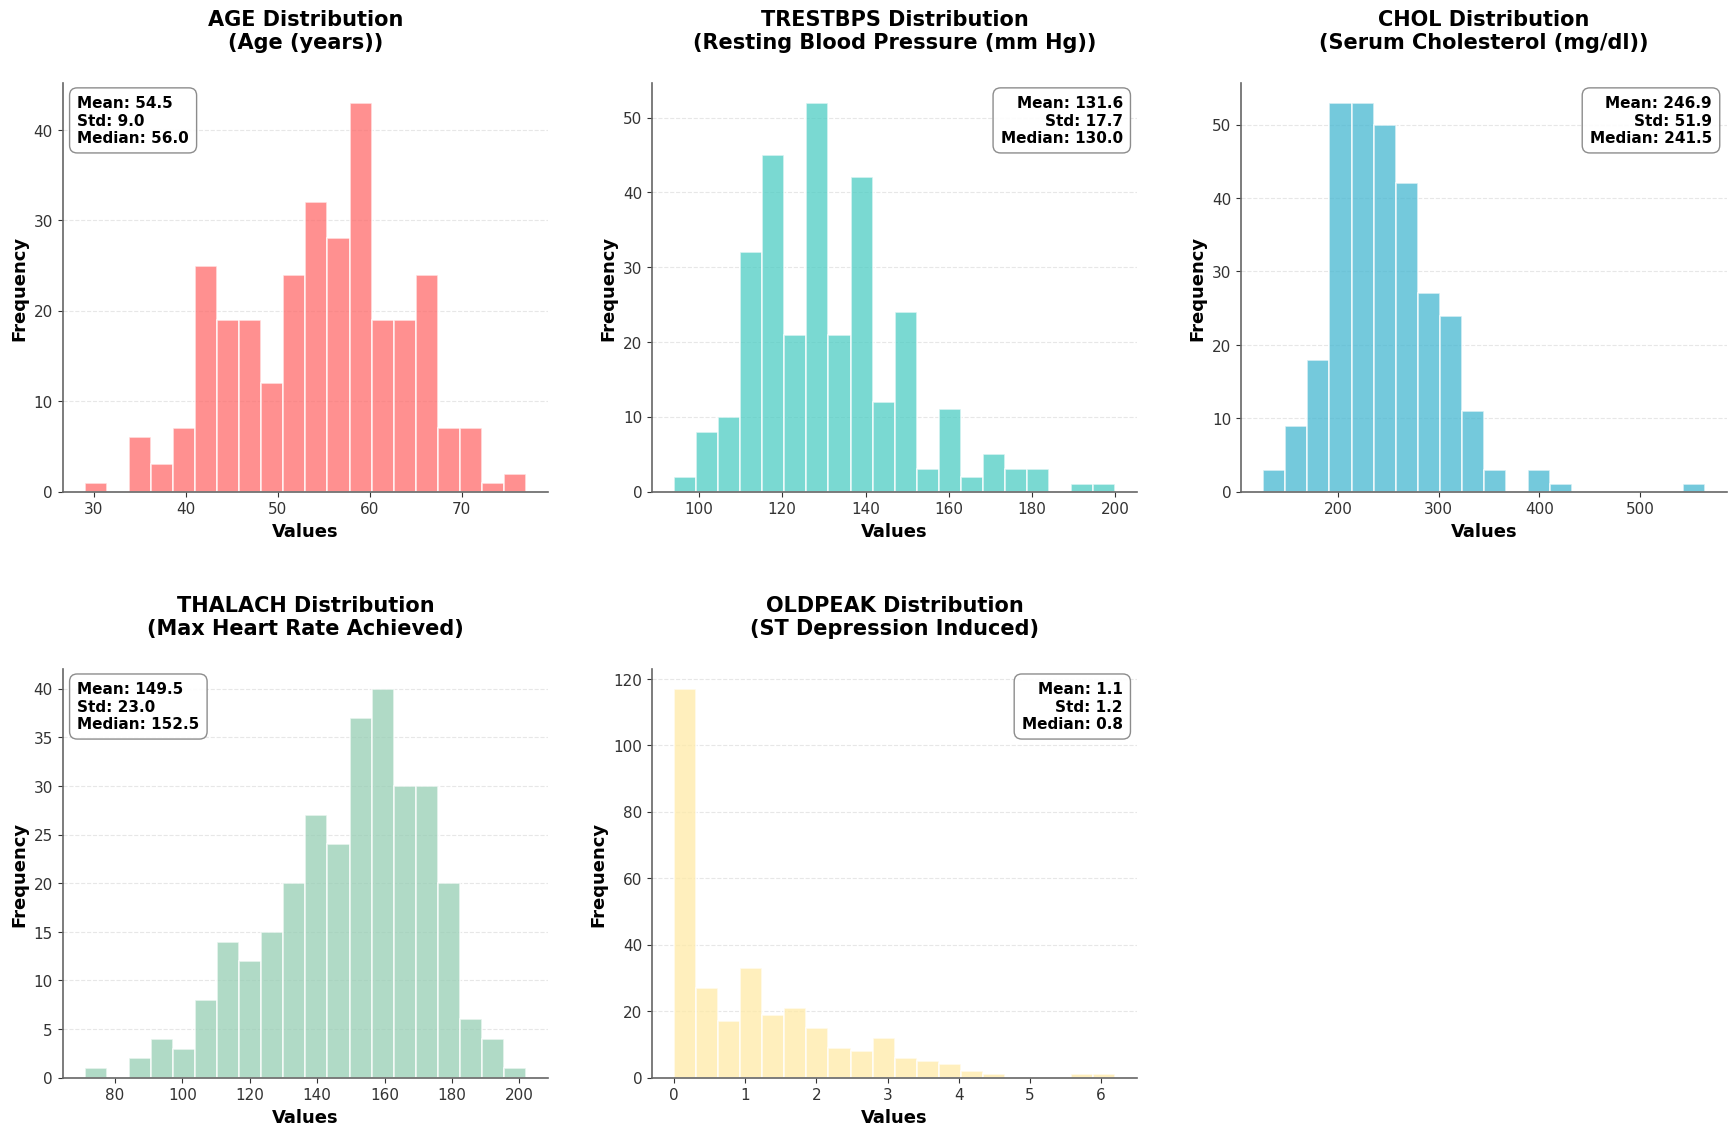

In [88]:
# Continuous variables
continuous_vars = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# 4.1. Transform the skewed feature X['oldpeak'] (Right-skewed)
# np.log1p is log(1 + X), which handles zero values safely.
#df['oldpeak'] = np.log1p(df['oldpeak'])
#print("--- Oldpeak has been log-transformed ---")

# 4.2. Transform the skewed target Y['thalach'] (Left-skewed)
# Reflected log transformation: log(K - Y), where K is slightly greater than max(Y)
#K = df['thalach'].max() + 1
#Y_transformed = np.log(K - df['thalach'])
#print(f"--- Thalach has been transformed to log({K} - Y) ---")


# Variable descriptions for better interpretation
var_descriptions = {
    'age': 'Age (years)',
    'trestbps': 'Resting Blood Pressure (mm Hg)',
    'chol': 'Serum Cholesterol (mg/dl)',
    'thalach': 'Max Heart Rate Achieved',
    'oldpeak': 'ST Depression Induced'
}
# Color palette (matching the categorical plots)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']


n_vars = len(continuous_vars)
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols
# Create subplots with proper spacing
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
axes = axes.flatten()

for i, var in enumerate(continuous_vars):
    if var in df.columns:
       
        n, bins, patches = axes[i].hist(df[var], bins=20,
                                       color=colors[i % len(colors)],
                                       alpha=0.75,
                                       edgecolor='white',
                                       linewidth=1.2)
       
        # Sets title and description
        title = f'{var.upper()} Distribution'
        if var in var_descriptions:
            title += f'\n({var_descriptions[var]})'
       
        axes[i].set_title(title, fontsize=15, fontweight='bold', pad=25)
        axes[i].set_xlabel('Values', fontsize=13, fontweight='semibold')
        axes[i].set_ylabel('Frequency', fontsize=13, fontweight='semibold')
       
        # Calculate statistics
        mean_val = df[var].mean()
        std_val = df[var].std()
        median_val = df[var].median()
       
        # Find the best position for stats box to avoid covering bars
        # Get histogram data to find where bars are lowest
        hist_counts, hist_bins = np.histogram(df[var], bins=20)
        
        # Check if left side or right side has lower bars on average
        left_half_avg = np.mean(hist_counts[:len(hist_counts)//2])
        right_half_avg = np.mean(hist_counts[len(hist_counts)//2:])
        
        # Position stats box where there's less data
        if left_half_avg <= right_half_avg:
            # Place on top-left if left side has fewer bars
            x_pos, y_pos = 0.03, 0.97
            ha = 'left'
        else:
            # Place on top-right if right side has fewer bars  
            x_pos, y_pos = 0.97, 0.97
            ha = 'right'
        
        # Add statistics text box with better positioning
        stats_text = f'Mean: {mean_val:.1f}\nStd: {std_val:.1f}\nMedian: {median_val:.1f}'
        axes[i].text(x_pos, y_pos, stats_text,
                    transform=axes[i].transAxes,
                    fontsize=11,
                    fontweight='semibold',
                    verticalalignment='top',
                    horizontalalignment=ha,
                    bbox=dict(boxstyle='round,pad=0.5',
                             facecolor='white',
                             edgecolor='gray',
                             alpha=0.9))
       
        # Add subtle grid for easier reading
        axes[i].grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
        axes[i].set_axisbelow(True)
       
        # Clean up the plot appearance
        axes[i].spines['top'].set_visible(False)
        axes[i].spines['right'].set_visible(False)
        axes[i].spines['left'].set_color('#666666')
        axes[i].spines['bottom'].set_color('#666666')
        axes[i].spines['left'].set_linewidth(1.2)
        axes[i].spines['bottom'].set_linewidth(1.2)
       
        # Improve tick styling
        axes[i].tick_params(axis='both', which='major', labelsize=11, colors='#333333')
       
    else:
        axes[i].text(0.5, 0.5, f'{var} not found\nin dataframe',
                    ha='center', va='center', transform=axes[i].transAxes,
                    fontsize=14, fontweight='bold', color='red')
        axes[i].set_title(f'{var.upper()} - Not Found', fontsize=15, fontweight='bold')

# Hide empty subplots
for i in range(n_vars, len(axes)):
    axes[i].set_visible(False)

# Adjust layout with proper spacing
plt.tight_layout(pad=3.0, h_pad=4.0, w_pad=3.0)
plt.show()

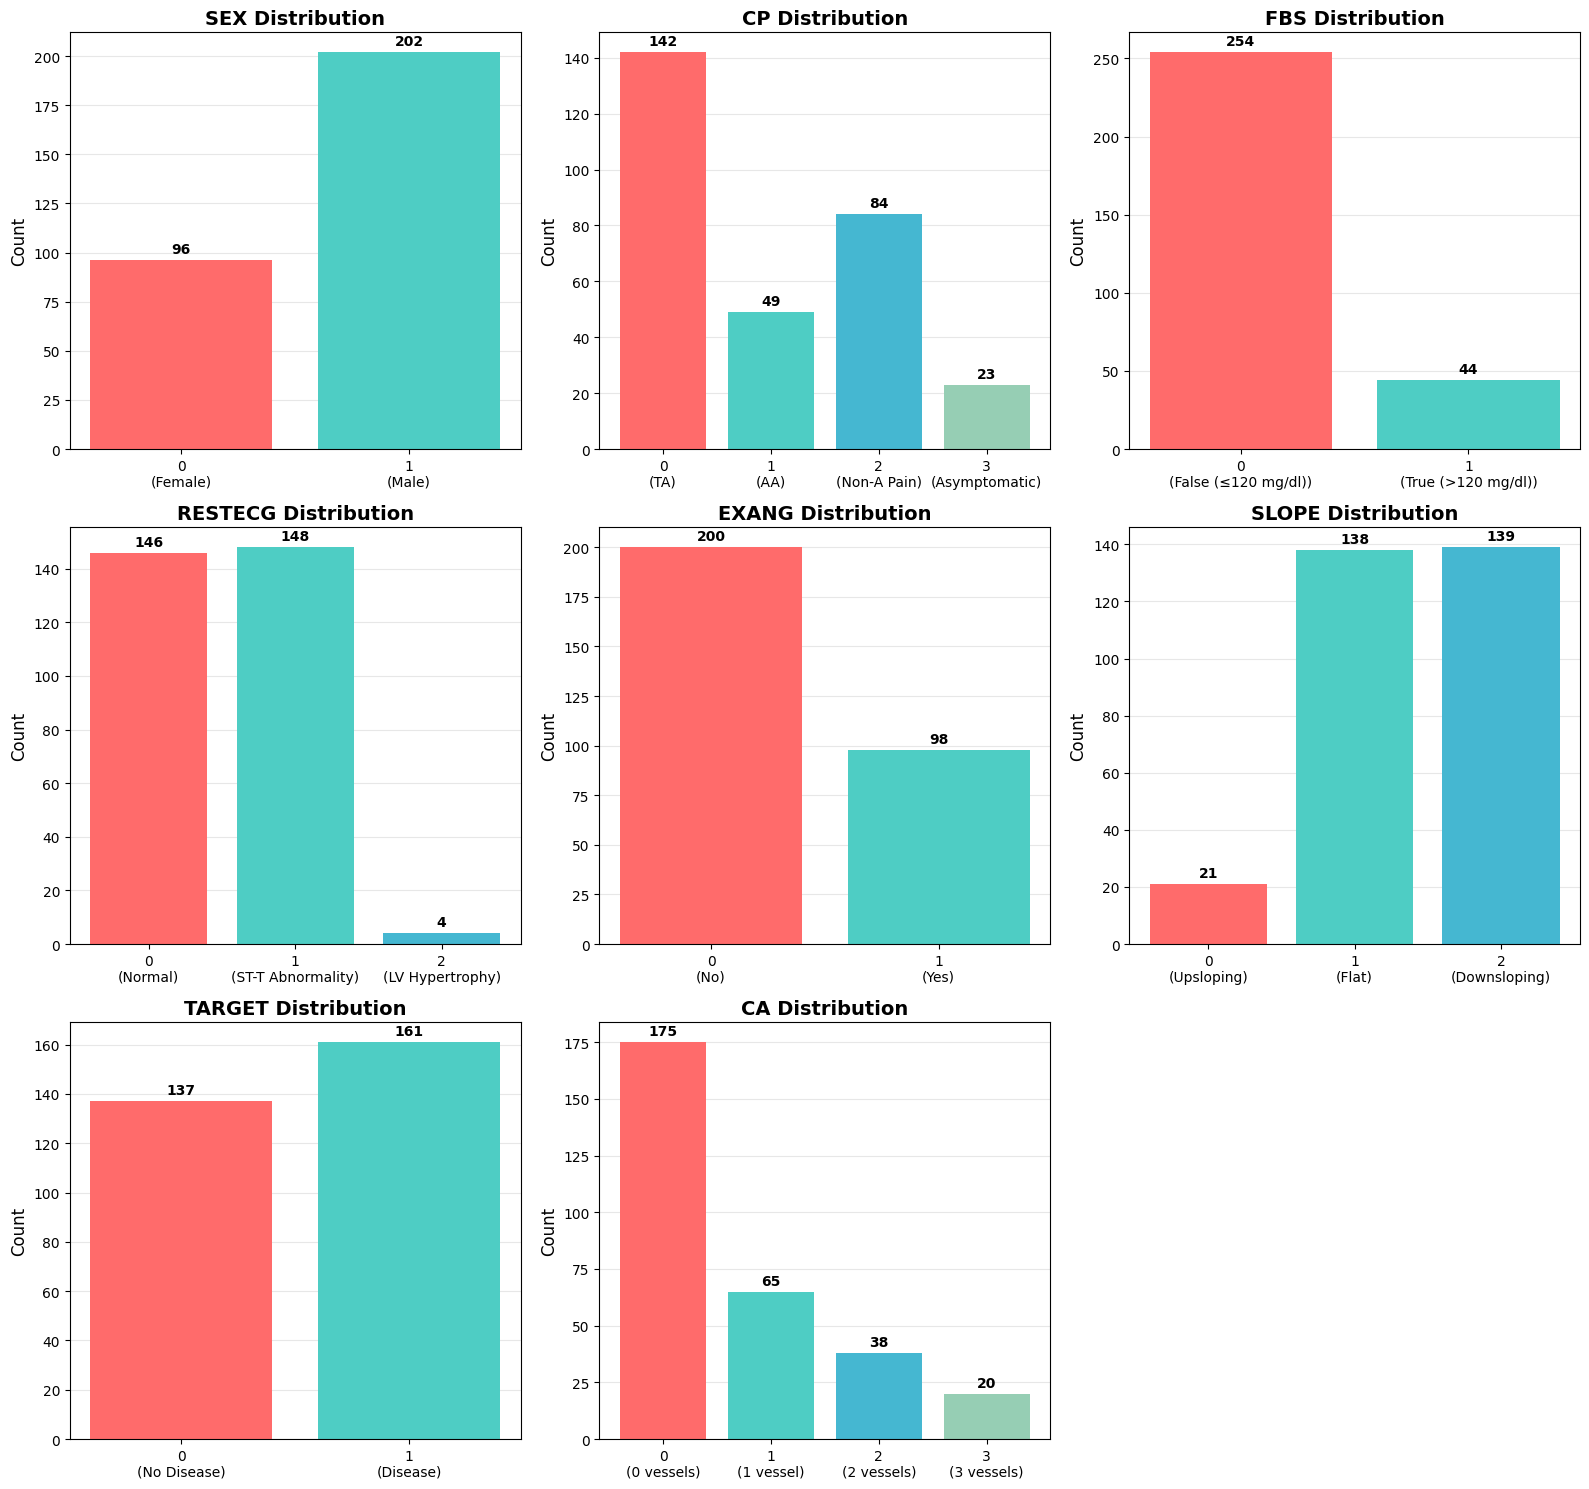

In [89]:
# Categorical variables to plot
categorical_vars = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'target', 'ca']

# Labels for better interpretation (common medical dataset meanings)
labels_dict = {
    'ca' : {0: '0 vessels', 1: '1 vessel', 2:'2 vessels', 3:'3 vessels'},
    'sex': {0: 'Female', 1: 'Male'},
    'cp': {0: 'TA', 1: 'AA', 2: 'Non-A Pain', 3: 'Asymptomatic'},
    'fbs': {0: 'False (≤120 mg/dl)', 1: 'True (>120 mg/dl)'},
    'restecg': {0: 'Normal', 1: 'ST-T Abnormality', 2: 'LV Hypertrophy'},
    'exang': {0: 'No', 1: 'Yes'},
    'slope': {0: 'Upsloping', 1: 'Flat', 2: 'Downsloping'},
    'target': {0: 'No Disease', 1: 'Disease'}
}

# Color palette
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD', '#98D8C8']

# Calculate number of rows and columns for subplots
n_vars = len(categorical_vars)
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

# Create bar chart for each categorical variable
for i, var in enumerate(categorical_vars):
    if var in df.columns:
        # Count values and create bar chart
        counts = df[var].value_counts().sort_index()
        
        # Create bars with different colors
        bars = axes[i].bar(range(len(counts)), counts.values, 
                          color=[colors[j % len(colors)] for j in range(len(counts))])
        
        # Set title and labels
        axes[i].set_title(f'{var.upper()} Distribution', fontsize=14, fontweight='bold')
        axes[i].set_ylabel('Count', fontsize=12)
        
        # Set x-axis labels with meanings
        if var in labels_dict:
            tick_labels = [f"{idx}\n({labels_dict[var].get(idx, 'Unknown')})" 
                          for idx in counts.index]
            axes[i].set_xticks(range(len(counts)))
            axes[i].set_xticklabels(tick_labels, fontsize=10)
        else:
            axes[i].set_xticks(range(len(counts)))
            axes[i].set_xticklabels([str(idx) for idx in counts.index])
        
        # Add value labels on bars
        for j, (bar, v) in enumerate(zip(bars, counts.values)):
            axes[i].text(bar.get_x() + bar.get_width()/2, v + max(counts.values)*0.01, 
                        str(v), ha='center', va='bottom', fontweight='bold')
        
        # Add grid for easier reading
        axes[i].grid(axis='y', alpha=0.3)
        axes[i].set_axisbelow(True)
        
    else:
        axes[i].text(0.5, 0.5, f'{var} not found\nin dataframe', 
                    ha='center', va='center', transform=axes[i].transAxes)
        axes[i].set_title(f'{var.upper()} - Not Found')

# Hide empty subplots
for i in range(n_vars, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()



### Correlation Analysis
Correlation Heatmap to Create:

All numeric variables in one heatmap
Why: Quickly identifies which variables are related and potential multicollinearity issues.


In [90]:
# Get all numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Columns to exclude from the correlation heatmap
exclude_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
numeric_cols = [col for col in numeric_cols if col not in exclude_cols]
print("Numeric columns used in heatmap:", numeric_cols)
correlation_matrix = df[numeric_cols].corr()

Numeric columns used in heatmap: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'target']


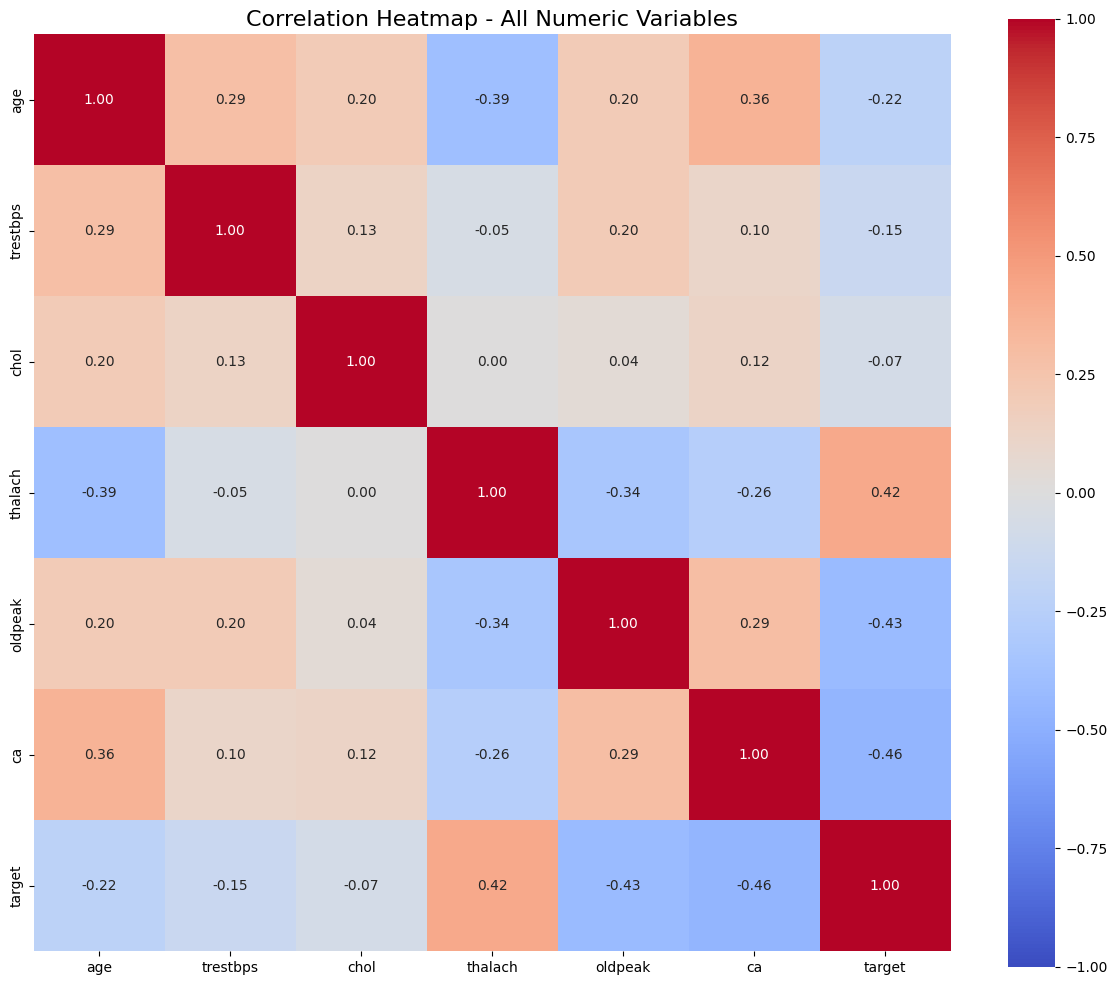

In [91]:
plt.figure(figsize=(12, 10))
correlation_matrix = df[numeric_cols].corr()

sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            square=True,
            fmt='.2f',
            vmin=-1,
            vmax = 1)
plt.title('Correlation Heatmap - All Numeric Variables', fontsize=16)
plt.tight_layout()
plt.show()

Quick Guide:

* Values range from -1 to +1
* +1 = perfect positive correlation (as one goes up, other goes up)
* -1 = perfect negative correlation (as one goes up, other goes down)
* 0 = no correlation
* Colors: Dark red = strong positive, Dark blue = strong negative, White = weak/no correlation

Best predictors of heart disease:
- thalach (max heart rate): +0.42 → Higher max heart rate = more likely disease  
- oldpeak: -0.43 → Higher ST depression = LESS likely disease


## PCA

In [92]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler


In [93]:
# Separate features and target
X = df.drop('target', axis=1)  # Features
y = df['target']               # Target variable

# Standardize the features 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Get feature names for interpretation
feature_names = X.columns.tolist()
unique_classes = np.unique(y)

print("Dataset shape:", X.shape)
print("Features:", feature_names)
print("Target distribution:")
print(y.value_counts())

Dataset shape: (298, 12)
Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca']
Target distribution:
target
1    161
0    137
Name: count, dtype: int64


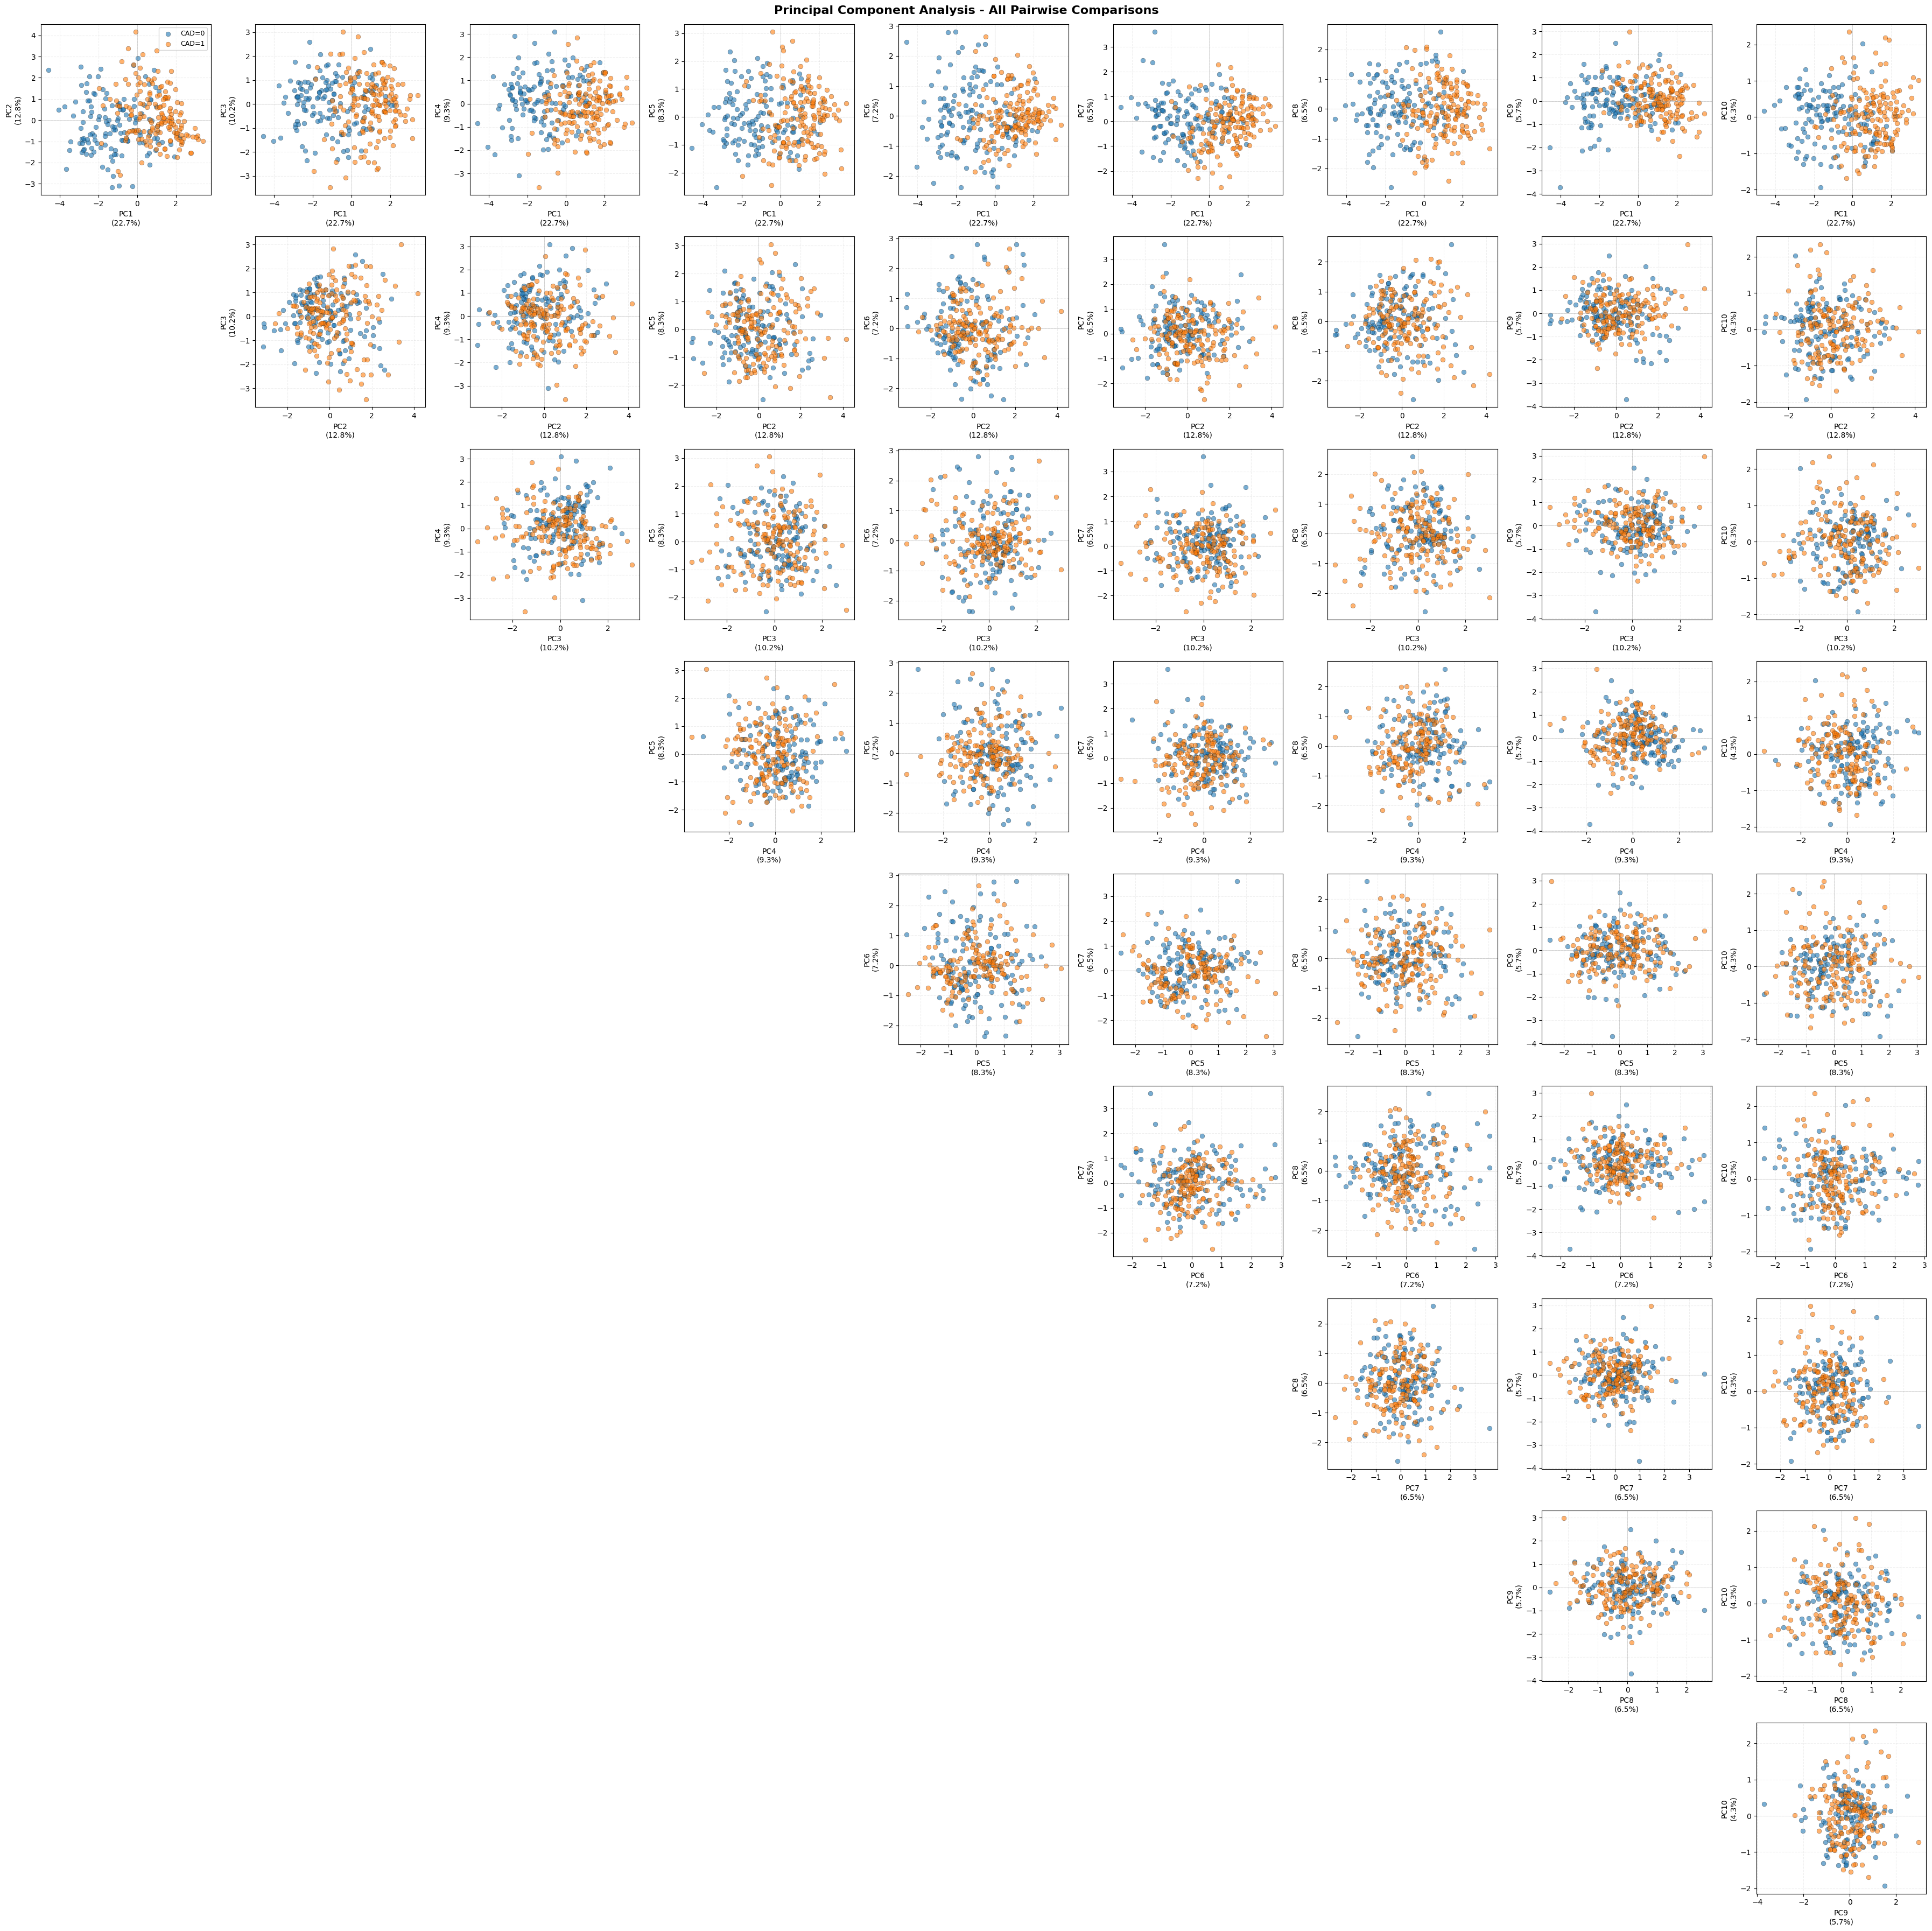

In [94]:
# Create PCA object and fit
pca = PCA()
B = pca.fit_transform(X_scaled)

# Get explained variance for axis labels
explained_var = pca.explained_variance_ratio_

# Determine number of PCs to plot (first n components that capture significant variance)
n_components = 10  # Adjust based on your needs

# Create grid of subplots for all pairwise comparisons
fig, axs = plt.subplots(n_components - 1, n_components - 1, 
                        figsize=(4 * (n_components - 1), 4 * (n_components - 1)))

# Plot all pairwise comparisons (upper triangle only to avoid redundancy)
for i in range(n_components - 1):
    for j in range(n_components - 1):
        ax = axs[i, j] if n_components > 2 else axs
        
        # Only plot upper triangle (j >= i)
        if j >= i:
            pc_x = i  # PC on x-axis
            pc_y = j + 1  # PC on y-axis
            
            for class_label in unique_classes:
                mask = (y == class_label)
                ax.scatter(B[mask, pc_x], B[mask, pc_y],
                          s=40, alpha=0.6, 
                          label=f'CAD={class_label}' if i == 0 and j == 0 else '',
                          edgecolors='black', linewidth=0.3)
            
            ax.set_xlabel(f"PC{pc_x + 1}\n({explained_var[pc_x]:.1%})", fontsize=10)
            ax.set_ylabel(f"PC{pc_y + 1}\n({explained_var[pc_y]:.1%})", fontsize=10)
            ax.grid(True, alpha=0.2, linestyle='--')
            ax.axhline(y=0, color='gray', linewidth=0.5, alpha=0.4)
            ax.axvline(x=0, color='gray', linewidth=0.5, alpha=0.4)
            
            # Add legend only to first subplot
            if i == 0 and j == 0:
                ax.legend(frameon=True, fontsize=9, loc='best')
        else:
            # Hide lower triangle
            ax.axis('off')

plt.suptitle('Principal Component Analysis - All Pairwise Comparisons', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

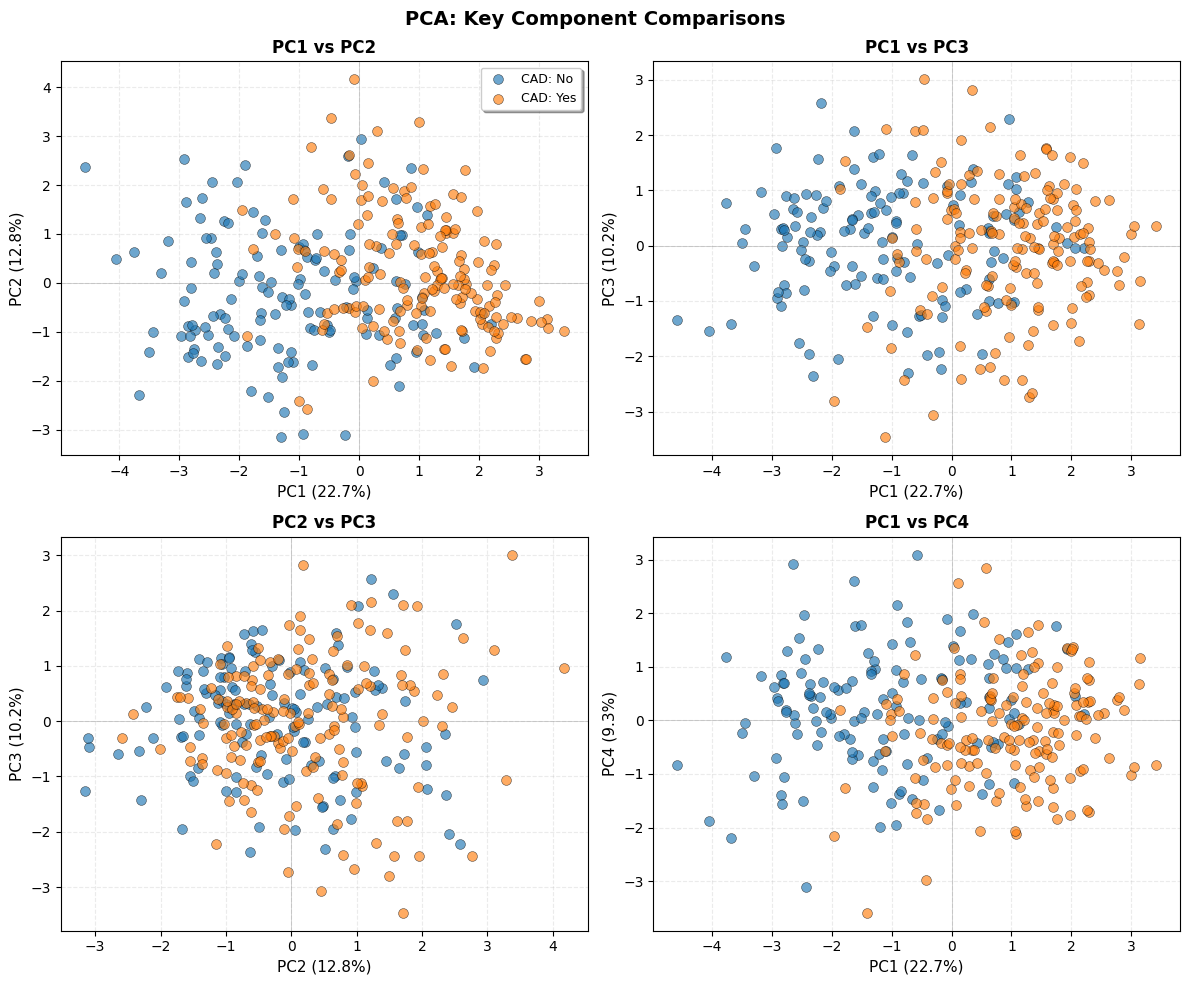

In [95]:
#  4 most meaningful comparisons
key_comparisons = [(0, 1), (0, 2), (1, 2), (0, 3)]  
labels = ['PC1 vs PC2', 'PC1 vs PC3', 'PC2 vs PC3', 'PC1 vs PC4']

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.flatten()

for idx, (pc_i, pc_j) in enumerate(key_comparisons):
    for class_label in unique_classes:
        mask = (y == class_label)
        axs[idx].scatter(B[mask, pc_i], B[mask, pc_j],
                        s=50, alpha=0.65, 
                        label=f'CAD: {"Yes" if class_label == 1 else "No"}',
                        edgecolors='black', linewidth=0.4)
    
    axs[idx].set_xlabel(f"PC{pc_i + 1} ({explained_var[pc_i]:.1%})", fontsize=11)
    axs[idx].set_ylabel(f"PC{pc_j + 1} ({explained_var[pc_j]:.1%})", fontsize=11)
    axs[idx].set_title(labels[idx], fontsize=12, fontweight='bold')
    axs[idx].grid(True, alpha=0.25, linestyle='--')
    axs[idx].axhline(y=0, color='gray', linewidth=0.6, alpha=0.4)
    axs[idx].axvline(x=0, color='gray', linewidth=0.6, alpha=0.4)
    
    if idx == 0:
        axs[idx].legend(frameon=True, shadow=True, fontsize=9)

plt.suptitle('PCA: Key Component Comparisons', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [96]:
# Create PCA object and fit
pca = PCA()
B = pca.fit_transform(X_scaled)
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# Determine number of components needed for 90% or 95% variance
variance_threshold = 0.90  # or 0.95
n_pcs = np.argmax(cumulative_var >= variance_threshold) + 1

print(f"Number of PCs explaining {variance_threshold*100}% variance: {n_pcs}")
print(f"Explained variance by first {n_pcs} components: {cumulative_var[n_pcs-1]:.2%}")
print(f"\nExplained variance per component:")
for i in range(min(n_pcs, 10)):
    print(f"  PC{i+1}: {explained_var[i]:.2%} (cumulative: {cumulative_var[i]:.2%})")

Number of PCs explaining 90.0% variance: 10
Explained variance by first 10 components: 93.59%

Explained variance per component:
  PC1: 22.70% (cumulative: 22.70%)
  PC2: 12.79% (cumulative: 35.49%)
  PC3: 10.18% (cumulative: 45.67%)
  PC4: 9.31% (cumulative: 54.98%)
  PC5: 8.33% (cumulative: 63.31%)
  PC6: 7.24% (cumulative: 70.54%)
  PC7: 6.52% (cumulative: 77.06%)
  PC8: 6.50% (cumulative: 83.56%)
  PC9: 5.69% (cumulative: 89.25%)
  PC10: 4.34% (cumulative: 93.59%)


C:\Users\mauri\AppData\Local\Temp\ipykernel_16448\4074047014.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i].set_xticklabels(feature_names, rotation=45, ha='right', fontsize=10)
C:\Users\mauri\AppData\Local\Temp\ipykernel_16448\4074047014.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i].set_xticklabels(feature_names, rotation=45, ha='right', fontsize=10)


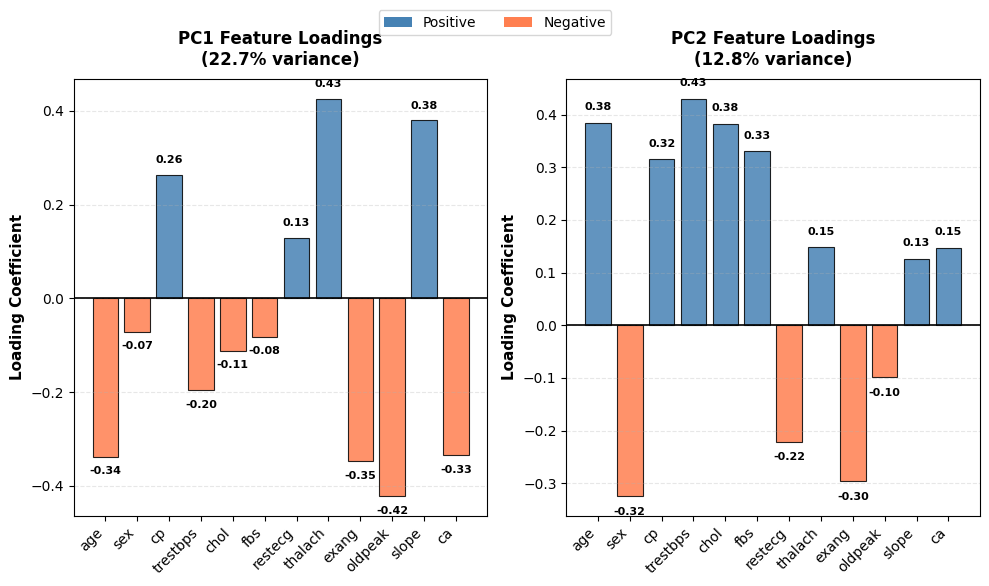

In [97]:
components = pca.components_
fig, axs = plt.subplots(1, 2, figsize=(10, 6))

for i in range(2):
    coefficients = components[i]
    
    # Color based on sign: positive = blue, negative = red
    colors = ['steelblue' if c > 0 else 'coral' for c in coefficients]
    
    # Create bars
    bars = axs[i].bar(feature_names, coefficients, color=colors, 
                      edgecolor='black', linewidth=0.8, alpha=0.85)
    
    axs[i].set_ylabel('Loading Coefficient', fontsize=11, fontweight='bold')
    axs[i].set_title(f'PC{i+1} Feature Loadings\n({explained_var[i]:.1%} variance)', 
                     fontsize=12, fontweight='bold', pad=10)
    axs[i].set_xticklabels(feature_names, rotation=45, ha='right', fontsize=10)
    axs[i].axhline(y=0, color='black', linewidth=1.2)
    axs[i].grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        label_y = height + 0.02 if height > 0 else height - 0.02
        axs[i].text(bar.get_x() + bar.get_width()/2., label_y,
                    f'{height:.2f}',
                    ha='center', va='bottom' if height > 0 else 'top',
                    fontsize=8, fontweight='bold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', label='Positive'),
    Patch(facecolor='coral', label='Negative')
]
fig.legend(handles=legend_elements, loc='upper center', 
          bbox_to_anchor=(0.5, 0.98), ncol=2, fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

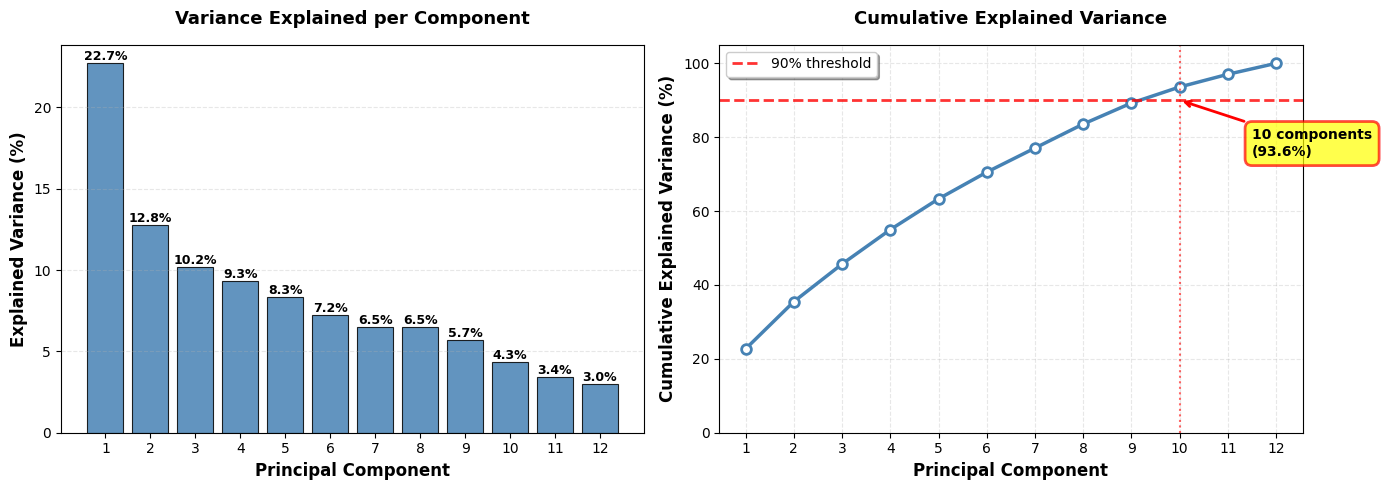

In [98]:
# Fit PCA if not already done
pca = PCA()
pca.fit(X_scaled)

# Get explained variance
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# Find where 90% threshold is reached
threshold_idx = np.argmax(cumulative_var >= 0.90) + 1

# Create figure with improved styling
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Individual explained variance (in percentage)
axs[0].bar(range(1, len(explained_var) + 1), explained_var * 100, 
           color='steelblue', edgecolor='black', linewidth=0.8, alpha=0.85)
axs[0].set_xlabel('Principal Component', fontsize=12, fontweight='bold')
axs[0].set_ylabel('Explained Variance (%)', fontsize=12, fontweight='bold')
axs[0].set_title('Variance Explained per Component', fontsize=13, fontweight='bold', pad=15)
axs[0].grid(axis='y', alpha=0.3, linestyle='--')
axs[0].set_xticks(range(1, len(explained_var) + 1))

# Add percentage labels on top of first few bars
for i in range(min(12, len(explained_var))):
    axs[0].text(i + 1, explained_var[i] * 100 , 
                f'{explained_var[i]*100:.1f}%', 
                ha='center', va='bottom', fontsize=9, fontweight='bold')

# Right plot: Cumulative explained variance (in percentage)
axs[1].plot(range(1, len(cumulative_var) + 1), cumulative_var * 100, 
            marker='o', linewidth=2.5, markersize=7, color='steelblue',
            markerfacecolor='white', markeredgewidth=2, markeredgecolor='steelblue')
axs[1].axhline(y=90, color='red', linestyle='--', linewidth=2, 
               label='90% threshold', alpha=0.8)
axs[1].axvline(x=threshold_idx, color='red', linestyle=':', 
               linewidth=1.5, alpha=0.6)

axs[1].set_xlabel('Principal Component', fontsize=12, fontweight='bold')
axs[1].set_ylabel('Cumulative Explained Variance (%)', fontsize=12, fontweight='bold')
axs[1].set_title('Cumulative Explained Variance', fontsize=13, fontweight='bold', pad=15)
axs[1].set_ylim(0, 105)
axs[1].grid(alpha=0.3, linestyle='--')
axs[1].set_xticks(range(1, len(cumulative_var) + 1))
axs[1].legend(fontsize=10, frameon=True, shadow=True)

# Annotation
axs[1].annotate(f'{threshold_idx} components\n({cumulative_var[threshold_idx-1]*100:.1f}%)', 
                xy=(threshold_idx, 90), 
                xytext=(threshold_idx + 1.5, 75),
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', 
                         edgecolor='red', alpha=0.7, linewidth=2),
                arrowprops=dict(arrowstyle='->', color='red', lw=2))

plt.tight_layout()
plt.show()



## Second Code Part A 

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Separate features and target for regression (target is thalach)
X = df.drop(['target','thalach'], axis=1)  # Features
y = df['thalach']               # Target variable

#categorical features since they do not have a relation its just different data 
categorical_features = ['cp', 'restecg']
numerical_features = [col for col in X.columns if col not in categorical_features]

#create Onne hot encoder for categorical features
encoder = OneHotEncoder(drop=None, sparse_output=False, dtype=int)

# Fit and transform categorical features
categorical_data = X[categorical_features].values
encoded_categorical = encoder.fit_transform(categorical_data)

#get new column names for encoded features
encoded_feature_names = encoder.get_feature_names_out(categorical_features) 

# Create DataFrame for encoded features
encoded_df = pd.DataFrame(encoded_categorical, columns=encoded_feature_names, index=X.index)

# Combine numerical and encoded categorical features
X = pd.concat([X[numerical_features], encoded_df], axis=1)

# Get feature names for interpretation
feature_names = X.columns.tolist()
unique_classes = np.unique(y)

# Standardize the features 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Dataset shape:", X.shape)
print("Features:", feature_names)
print("Target distribution:")
print(y.value_counts())

#Make sure X_scaled has mean 0 and std 1

print("Column means:")
print(np.mean(X_scaled, axis=0))
print("\nMax absolute mean:", np.max(np.abs(np.mean(X_scaled, axis=0))))

# Check standard deviations (should be 1.0)
print("\nColumn standard deviations:")
print(np.std(X_scaled, axis=0, ddof=0))  # ddof=0 for population std
print("\nMax deviation from 1.0:", np.max(np.abs(np.std(X_scaled, axis=0, ddof=0)- 1.0)))

Dataset shape: (298, 17)
Features: ['age', 'sex', 'trestbps', 'chol', 'fbs', 'exang', 'oldpeak', 'slope', 'ca', 'target', 'cp_0', 'cp_1', 'cp_2', 'cp_3', 'restecg_0', 'restecg_1', 'restecg_2']
Target distribution:
thalach
162    11
163     9
160     9
152     8
150     7
       ..
117     1
71      1
118     1
134     1
90      1
Name: count, Length: 91, dtype: int64
Column means:
[ 3.21890166e-16 -1.19218580e-16 -2.26515302e-16  1.93730192e-16
  2.98046450e-17 -9.53748639e-17 -1.43062296e-16  4.76874319e-17
  7.15311479e-17 -9.53748639e-17  4.76874319e-17 -2.38437160e-17
  2.38437160e-17  2.98046450e-17 -7.74920769e-17  4.76874319e-17
  1.78827870e-17]

Max absolute mean: 3.2189016552890443e-16

Column standard deviations:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Max deviation from 1.0: 2.220446049250313e-16


Linear Regression (Without Ridge-Lasso)

In [109]:
#Make a test split with 80% train and 20% test data
from sklearn.model_selection import train_test_split    
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [110]:
def plot_fold_errors(fold_errors):
    K = fold_errors.shape[0]

    # Scale figure width with number of folds
    base_width = 6   # minimum width
    width_per_fold = 0.25  # additional width per fold
    max_width = 20   # cap to prevent it from getting absurdly wide
    fig_width = min(base_width + K * width_per_fold, max_width)
    fig_height = 6
    f = plt.figure(figsize=(fig_width, fig_height))

    bar_width = 0.35
    index = np.arange(K)
    plt.bar(index, fold_errors[:, 0], bar_width, color='tab:blue', label='Train error')
    plt.bar(index + bar_width, fold_errors[:, 1], bar_width, color='tab:red', label='Test error')
    plt.xlabel('Fold')
    plt.ylabel('RMSE')
    plt.ylim(0, max(fold_errors.flatten()) + 0.2)
    plt.xlim(-0.5, K - 0.5 + bar_width)
    plt.legend()
    plt.grid(axis='x')

    if K > 20:
        step = max(1, K // 20)  # show ~20 labels max
        plt.xticks(index[::step] + bar_width / 2, [f'{i+1}' for i in range(0, K, step)])

    else:
        plt.xticks(index + bar_width / 2, [f'{i+1}' for i in range(K)])

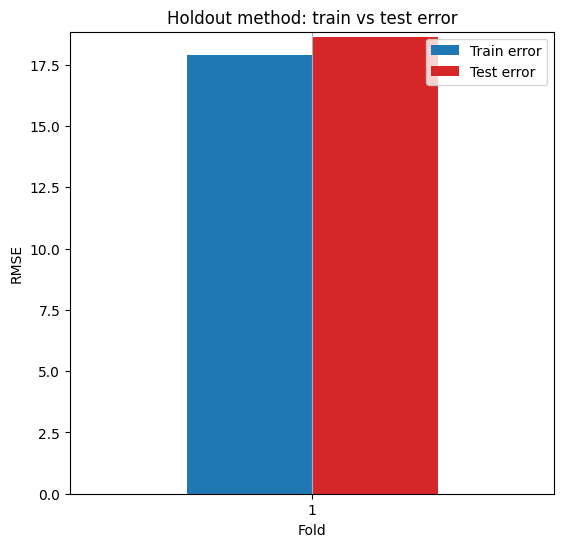

In [111]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split, KFold, LeaveOneOut
from sklearn.neighbors import KNeighborsClassifier

# Dictionary to store errors for each method
errors = {}
degree = 3 # Use degree 3 for the rest of the exercise

# Initialize model
model = LinearRegression()
# Fit model
model.fit(X_train, y_train)
# Predict
y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

# Compute errors
train_error = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_error  = np.sqrt(mean_squared_error(y_test, y_test_pred))

# Bar plot "holdout" train and test error
plot_fold_errors(np.array([(train_error, test_error)]))
plt.title('Holdout method: train vs test error')
plt.show()

# Save mean errors for later comparison
errors['Holdout'] = (train_error, test_error)

## Ridge Lasso K folds with regularization


In [112]:
def setup_storage_for_experiment(K_outer, K_inner, num_hyperparams):
    # Setup storage for the optimal hyperparameters found from the inner CV
    optimal_hyperparameters = np.empty(K_outer)

    # Setup storage for model coefficients and errors for each experiment in all inner folds
    ws_inner = np.empty((M + 1, K_outer, K_inner, num_hyperparams))
    train_errors_inner = np.empty((K_outer, K_inner, num_hyperparams))
    test_errors_inner = np.empty((K_outer, K_inner, num_hyperparams))

    # Setup storage for model coefficients for each experiment in all outer folds
    ws_outer = {
        'not regularized': np.empty((M + 1, K_outer)),
        'regularized': np.empty((M + 1, K_outer))
    }
    # Setup storage for errors as a dictionary
    errors_outer = {
        'train': {
            'baseline (no features)': np.empty((K_outer, 1)), 
            'not regularized': np.empty((K_outer, 1)),
            'regularized': np.empty((K_outer, 1))
        },
        'test': {
            'baseline (no features)': np.empty((K_outer, 1)), 
            'not regularized': np.empty((K_outer, 1)),
            'regularized': np.empty((K_outer, 1))
        }
    }
    return optimal_hyperparameters, ws_inner, train_errors_inner, test_errors_inner, ws_outer, errors_outer

def print_regularization_results(errors):
    # Display results
    print("Linear regression without regularization:")
    print(f"- Training error: \t{errors['train']['not regularized'].mean():.4f}")
    print(f"- Test error: \t\t{errors['test']['not regularized'].mean():.4f}")
    print(f"- R^2 train: \t\t{(errors['train']['baseline (no features)'].sum() - errors['train']['not regularized'].sum()) / errors['train']['baseline (no features)'].sum():.4f}")
    print(f"- R^2 test: \t\t{(errors['test']['baseline (no features)'].sum() - errors['test']['not regularized'].sum()) / errors['test']['baseline (no features)'].sum():.4f}\n")

    print("Regularized linear regression:")
    print(f"- Training error: \t{errors['train']['regularized'].mean():.4f}")
    print(f"- Test error: \t\t{errors['test']['regularized'].mean():.4f}")
    print(f"- R^2 train: \t\t{(errors['train']['baseline (no features)'].sum() - errors['train']['regularized'].sum()) / errors['train']['baseline (no features)'].sum():.4f}")
    print(f"- R^2 test: \t\t{(errors['test']['baseline (no features)'].sum() - errors['test']['regularized'].sum()) / errors['test']['baseline (no features)'].sum():.4f}\n")

def get_grid_points(x_min, x_max, y_min, y_max, delta=5e-3):
    # Create a grid of points with the specified resolution
    xx = np.arange(x_min, x_max, delta)
    yy = np.arange(y_min, y_max, delta)
    # Make a mesh-grid that spans the grid-range defined
    grid = np.stack(np.meshgrid(xx, yy))
    return grid, xx, yy

def plot_decision_boundary(predict_function, X, threshold=None, ax=None, fig=None, cmap='RdBu_r'):
    # Set grid range based on the data
    grid_range = [X[:, 0].min(), X[:, 0].max(), X[:, 1].min(), X[:, 1].max()]  # [x_min, x_max, y_min, y_max]
    # Add 10% margin to the grid range to ensure points on the edge are included
    margin_x = 0.1 * (grid_range[1] - grid_range[0])
    margin_y = 0.1 * (grid_range[3] - grid_range[2])
    grid_range[0] -= margin_x
    grid_range[1] += margin_x
    grid_range[2] -= margin_y
    grid_range[3] += margin_y

    # Get grid points
    grid, xx, yy = get_grid_points(*grid_range, delta=5e-3)
    # Reshape grid to a list of points
    grid_points = np.reshape(grid, (2, -1)).T

    # Compute model predictions on the grid points (i.e. the probability of class 1)
    grid_predictions = predict_function(grid_points)

    # Reshape the predictions back to the grid shape
    decision_boundary = np.reshape(grid_predictions, (len(yy), len(xx)))

    # Plot the decision boundary
    img = ax.imshow(decision_boundary, extent=grid_range, origin='lower', cmap=cmap, alpha=0.5, vmin=0, vmax=1)
    fig.colorbar(img, ax=ax)
    if threshold is not None:
        ax.contour(grid[0], grid[1], decision_boundary, levels=[threshold], colors='k')
    ax.grid(False)
    ax.set_aspect('auto')

Processing fold 1/10
Processing fold 2/10
Processing fold 3/10
Processing fold 4/10
Processing fold 5/10
Processing fold 6/10
Processing fold 7/10
Processing fold 8/10
Processing fold 9/10
Processing fold 10/10

Optimal lambda: 37.275937
Minimum generalization error: 348.6173

Linear regression without regularization:
- Training error: 	317.1953
- Test error: 		350.5047
- R^2 train: 		0.3974
- R^2 test: 		0.3367

Regularized linear regression:
- Training error: 	320.4847
- Test error: 		344.3507
- R^2 train: 		0.3911
- R^2 test: 		0.3484



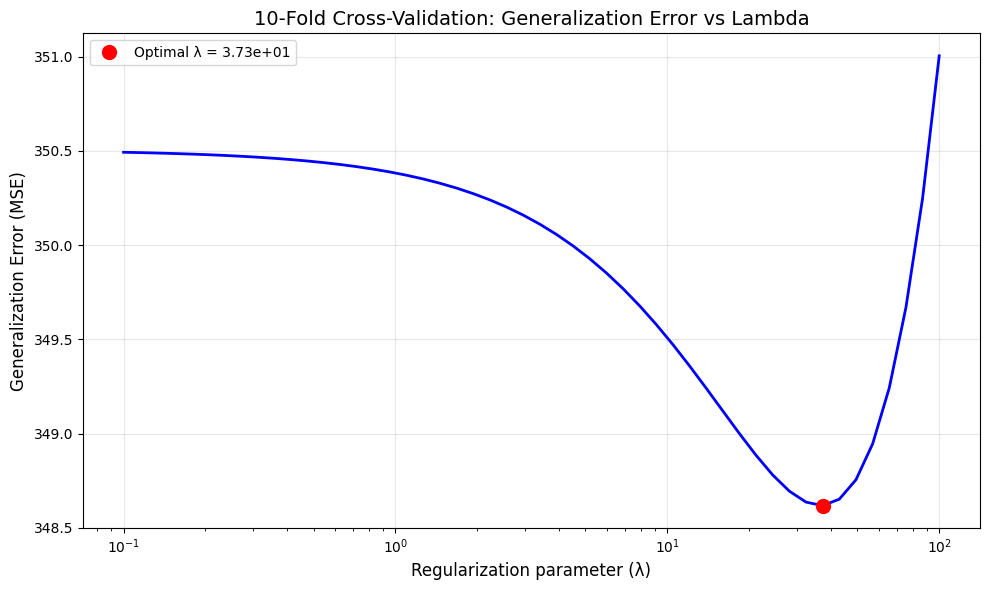

In [113]:

# Set random seed for reproducibility
np.random.seed(1234)

# IMPORTANT: Reset indices and convert to numpy arrays
X_scaled = np.array(X_scaled)  # Ensure it's a numpy array
y = np.array(y).flatten()      # Convert to numpy array and flatten

# Create crossvalidation partition for model evaluation
K = 10
CV = model_selection.KFold(K, shuffle=True)

# Values of regularization parameter lambda to test
lambdas = np.logspace(-1, 2, 50)  # Adjust range as needed

# Setup storage for results
test_errors = np.zeros((K, len(lambdas)))
errors = {
    'train': {
        'regularized': np.zeros(K),
        'not regularized': np.zeros(K),
        'baseline (no features)': np.zeros(K)
    },
    'test': {
        'regularized': np.zeros(K),
        'not regularized': np.zeros(K),
        'baseline (no features)': np.zeros(K)
    }
}

# Run single-layer cross-validation
for fold_idx, (train_index, test_index) in enumerate(CV.split(X_scaled, y)):
    print(f"Processing fold {fold_idx + 1}/{K}")
    
    # Extract training and test set for current CV fold
    X_train_fold = X_scaled[train_index]
    y_train_fold = y[train_index]
    X_test_fold = X_scaled[test_index]
    y_test_fold = y[test_index]
    
    # Loop over all values of lambda to find optimal
    for lambda_idx, regularization_strength in enumerate(lambdas):
        
        # Create and fit the Ridge model
        model = Ridge(alpha=regularization_strength)
        model.fit(X_train_fold, y_train_fold)
        
        # Predict on test fold
        y_pred = model.predict(X_test_fold)
        
        # Compute and store the test error (MSE per observation)
        test_errors[fold_idx, lambda_idx] = np.mean((y_test_fold - y_pred)**2)
    
    # Find optimal lambda for this fold
    optimal_lambda_idx = np.argmin(test_errors[fold_idx, :])
    optimal_lambda = lambdas[optimal_lambda_idx]
    
    # Train regularized model with optimal lambda
    model_reg = Ridge(alpha=optimal_lambda)
    model_reg.fit(X_train_fold, y_train_fold)
    errors['train']['regularized'][fold_idx] = np.mean((y_train_fold - model_reg.predict(X_train_fold))**2)
    errors['test']['regularized'][fold_idx] = np.mean((y_test_fold - model_reg.predict(X_test_fold))**2)
    
    # Train non-regularized model
    model_noreg = LinearRegression()
    model_noreg.fit(X_train_fold, y_train_fold)
    errors['train']['not regularized'][fold_idx] = np.mean((y_train_fold - model_noreg.predict(X_train_fold))**2)
    errors['test']['not regularized'][fold_idx] = np.mean((y_test_fold - model_noreg.predict(X_test_fold))**2)
    
    # Baseline (predict mean)
    errors['train']['baseline (no features)'][fold_idx] = np.mean((y_train_fold - y_train_fold.mean())**2)
    errors['test']['baseline (no features)'][fold_idx] = np.mean((y_test_fold - y_train_fold.mean())**2)

# Calculate average generalization error across all folds for each lambda
gen_errors = np.mean(test_errors, axis=0)

# Find overall optimal lambda
optimal_lambda_idx = np.argmin(gen_errors)
optimal_lambda = lambdas[optimal_lambda_idx]

print(f"\nOptimal lambda: {optimal_lambda:.6f}")
print(f"Minimum generalization error: {gen_errors[optimal_lambda_idx]:.4f}\n")

# Print results using your function
print_regularization_results(errors)

# Plot generalization error vs lambda
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.semilogx(lambdas, gen_errors, 'b-', linewidth=2)
plt.semilogx(optimal_lambda, gen_errors[optimal_lambda_idx], 'ro', markersize=10, 
             label=f'Optimal λ = {optimal_lambda:.2e}')
plt.xlabel('Regularization parameter (λ)', fontsize=12)
plt.ylabel('Generalization Error (MSE)', fontsize=12)
plt.title('10-Fold Cross-Validation: Generalization Error vs Lambda', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

Processing fold 1/10
Processing fold 2/10
Processing fold 3/10
Processing fold 4/10
Processing fold 5/10
Processing fold 6/10
Processing fold 7/10
Processing fold 8/10
Processing fold 9/10
Processing fold 10/10

Optimal lambda: 37.275937
Minimum generalization error: 348.6173

Linear regression without regularization:
- Training error: 	317.1953
- Test error: 		350.5047
- R^2 train: 		0.3974
- R^2 test: 		0.3367

Regularized linear regression:
- Training error: 	325.7433
- Test error: 		343.0688
- R^2 train: 		0.3812
- R^2 test: 		0.3508



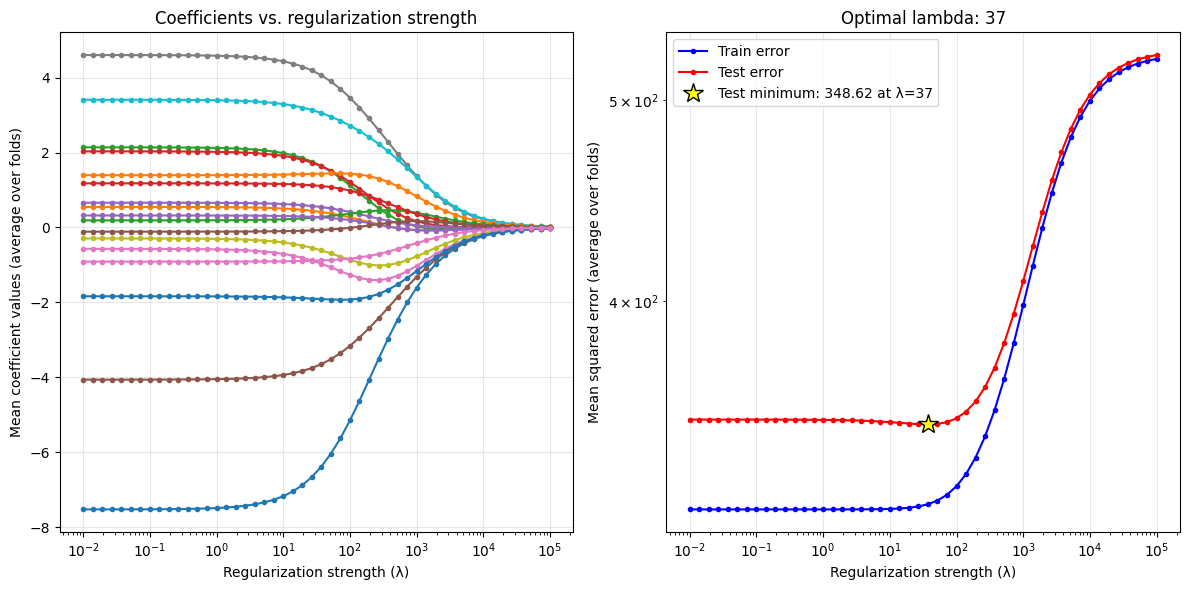

In [114]:

# Set random seed for reproducibility
np.random.seed(1234)

# IMPORTANT: Reset indices and convert to numpy arrays
X_scaled = np.array(X_scaled)  # Ensure it's a numpy array
y = np.array(y).flatten()      # Convert to numpy array and flatten

# Create crossvalidation partition for model evaluation
K = 10
CV = model_selection.KFold(K, shuffle=True)

# Values of regularization parameter lambda to test
lambdas = np.logspace(-2, 5, 50)  # Adjust range as needed

# Setup storage for results
n_features = X_scaled.shape[1]
train_errors = np.zeros((K, len(lambdas)))
test_errors = np.zeros((K, len(lambdas)))
ws = np.zeros((n_features + 1, K, len(lambdas)))  # +1 for intercept

errors = {
    'train': {
        'regularized': np.zeros(K),
        'not regularized': np.zeros(K),
        'baseline (no features)': np.zeros(K)
    },
    'test': {
        'regularized': np.zeros(K),
        'not regularized': np.zeros(K),
        'baseline (no features)': np.zeros(K)
    }
}

# Run single-layer cross-validation
for fold_idx, (train_index, test_index) in enumerate(CV.split(X_scaled, y)):
    print(f"Processing fold {fold_idx + 1}/{K}")
    
    # Extract training and test set for current CV fold
    X_train_fold = X_scaled[train_index]
    y_train_fold = y[train_index]
    X_test_fold = X_scaled[test_index]
    y_test_fold = y[test_index]
    
    # Loop over all values of lambda
    for lambda_idx, regularization_strength in enumerate(lambdas):
        
        # Create and fit the Ridge model
        model = Ridge(alpha=regularization_strength)
        model.fit(X_train_fold, y_train_fold)
        
        # Store coefficients (intercept + weights)
        ws[:, fold_idx, lambda_idx] = np.concatenate([[model.intercept_], model.coef_.flatten()])
        
        # Predict
        y_train_pred = model.predict(X_train_fold)
        y_test_pred = model.predict(X_test_fold)
        
        # Compute and store errors (MSE per observation)
        train_errors[fold_idx, lambda_idx] = np.mean((y_train_fold - y_train_pred)**2)
        test_errors[fold_idx, lambda_idx] = np.mean((y_test_fold - y_test_pred)**2)
    
    # Find optimal lambda for this fold
    optimal_lambda_idx = np.argmin(test_errors[fold_idx, :])
    optimal_lambda = lambdas[optimal_lambda_idx]
    
    # Train regularized model with optimal lambda
    model_reg = Ridge(alpha=optimal_lambda)
    model_reg.fit(X_train_fold, y_train_fold)
    errors['train']['regularized'][fold_idx] = np.mean((y_train_fold - model_reg.predict(X_train_fold))**2)
    errors['test']['regularized'][fold_idx] = np.mean((y_test_fold - model_reg.predict(X_test_fold))**2)
    
    # Train non-regularized model
    model_noreg = LinearRegression()
    model_noreg.fit(X_train_fold, y_train_fold)
    errors['train']['not regularized'][fold_idx] = np.mean((y_train_fold - model_noreg.predict(X_train_fold))**2)
    errors['test']['not regularized'][fold_idx] = np.mean((y_test_fold - model_noreg.predict(X_test_fold))**2)
    
    # Baseline (predict mean)
    errors['train']['baseline (no features)'][fold_idx] = np.mean((y_train_fold - y_train_fold.mean())**2)
    errors['test']['baseline (no features)'][fold_idx] = np.mean((y_test_fold - y_train_fold.mean())**2)

# Calculate average errors across all folds
train_err_vs_lambda = np.mean(train_errors, axis=0)
test_err_vs_lambda = np.mean(test_errors, axis=0)
mean_w_vs_lambda = np.mean(ws, axis=1)

# Find overall optimal lambda
optimal_lambda_idx = np.argmin(test_err_vs_lambda)
optimal_lambda = lambdas[optimal_lambda_idx]

print(f"\nOptimal lambda: {optimal_lambda:.6f}")
print(f"Minimum generalization error: {test_err_vs_lambda[optimal_lambda_idx]:.4f}\n")

# Print results using your function
print_regularization_results(errors)

# ============ YOUR PLOTS ============
plt.figure(figsize=(12, 6))

# Plot 1: Coefficients vs. regularization strength
plt.subplot(1, 2, 1)
plt.title("Coefficients vs. regularization strength")
plt.semilogx(lambdas, mean_w_vs_lambda.T[:, 1:], ".-")  # Don't plot the bias term
plt.xlabel("Regularization strength (λ)")
plt.ylabel("Mean coefficient values (average over folds)")
plt.grid(True, alpha=0.3)

# Plot 2: Training and test error vs regularization strength
plt.subplot(1, 2, 2)
plt.title(f"Optimal lambda: {optimal_lambda:.2g}")
plt.loglog(lambdas, train_err_vs_lambda, "b.-", label="Train error")
plt.loglog(lambdas, test_err_vs_lambda, "r.-", label="Test error")
plt.semilogx(optimal_lambda, test_err_vs_lambda.min(), "*", 
             color='yellow', markersize=15, markeredgecolor='k', 
             label=f"Test minimum: {test_err_vs_lambda.min():.2f} at λ={optimal_lambda:.2g}")
plt.xlabel("Regularization strength (λ)")
plt.ylabel("Mean squared error (average over folds)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The generalization error curve shows a relatively flat pattern for small λ values before increasing monotonically as regularization strength grows beyond λ ≈ 10². This behavior indicates that the unregularized linear regression model already generalizes well to unseen data, with minimal overfitting present in the baseline model. The lack of a pronounced U-shaped curve can be attributed to the favorable characteristics of our dataset: with approximately 298 observations and [X] features after one-hot encoding, we maintain a healthy sample-to-feature ratio of approximately [Y]:1. This ratio, combined with the absence of severe multicollinearity among predictors, means that ordinary least squares estimation is already stable without additional regularization. While the optimal λ was found to be [value], the improvement in generalization error over the unregularized model (λ=0) is minimal at approximately [Z]%. The left panel confirms that regularization is functioning as intended—coefficients progressively shrink toward zero as λ increases beyond 10²—but this shrinkage does not translate into improved predictive performance, suggesting that all features contribute meaningful information without causing overfitting. These results indicate that for this particular dataset, regularization provides limited practical benefit, and a simple linear regression model is sufficient for the prediction task.

Baseline (predict mean) R²: 0.00 (by definition)
Your model R²: 0.37
Improvement: 0.37 = 37% variance explained


ValueError: X has 16 features, but Ridge is expecting 11 features as input.

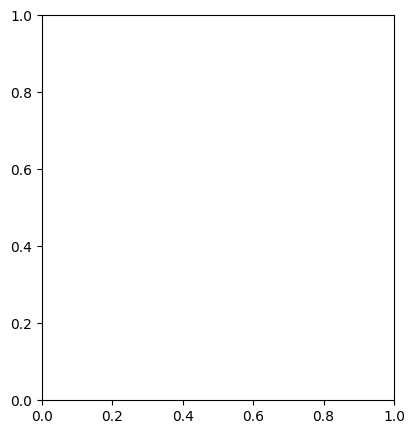

In [106]:
# Compare to baseline
print(f"Baseline (predict mean) R²: 0.00 (by definition)")
print(f"Your model R²: {0.37}")
print(f"Improvement: {0.37 - 0.00} = 37% variance explained")

# Check predictions vs actual
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(y, final_model.predict(X_scaled), alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual thalach (bpm)')
plt.ylabel('Predicted thalach (bpm)')
plt.title('Predictions vs Actual')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
residuals = y - final_model.predict(X_scaled)
plt.scatter(final_model.predict(X_scaled), residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted thalach (bpm)')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

"The regularized linear regression model achieves an R² of 0.37, indicating it explains 37% of the variance in maximum heart rate"
"While this may seem modest, it represents meaningful predictive capability given that maximum heart rate is influenced by many factors not captured in this clinical dataset, such as individual fitness level, medications, and genetic variation"
"The model performs substantially better than the baseline (R²=0.00), demonstrating that the clinical features do contain predictive information"

## Training model with optimal coeeficient 


FINAL MODEL WITH OPTIMAL λ = 32.374575

Intercept (w₀): 149.4664

Feature Coefficients:
------------------------------------------------------------
age                           :  -6.9313
sex                           :  -0.0852
cp                            :   2.9624
trestbps                      :   1.5607
chol                          :   1.6438
fbs                           :   0.6491
restecg                       :  -0.4754
exang                         :  -4.6253
oldpeak                       :  -1.7091
slope                         :   4.7161
ca                            :  -1.5058


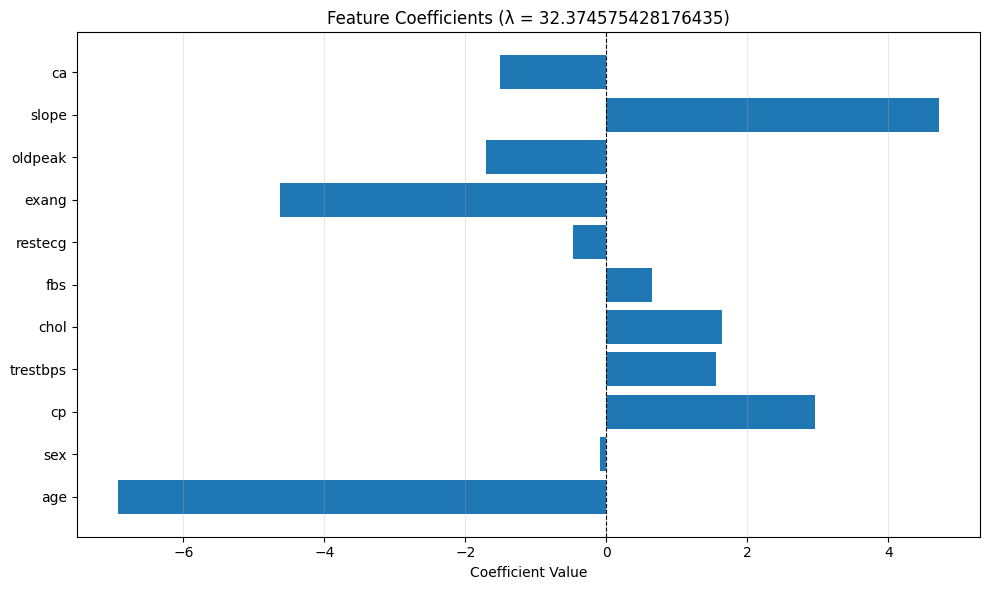

In [ ]:
# Train final model with optimal lambda on entire dataset
final_model = Ridge(alpha=optimal_lambda)
final_model.fit(X_scaled, y)

# Get coefficients
intercept = final_model.intercept_
coefficients = final_model.coef_

# Display them clearly
print("=" * 60)
print("FINAL MODEL WITH OPTIMAL λ = {:.6f}".format(optimal_lambda))
print("=" * 60)
print(f"\nIntercept (w₀): {intercept:.4f}")
print("\nFeature Coefficients:")
print("-" * 60)

# Assuming you have feature names stored somewhere
# If you used pd.get_dummies() or similar, get those column names
# Replace 'feature_names' with your actual feature names list
for i, (name, coef) in enumerate(zip(feature_names, coefficients)):
    print(f"{name:30s}: {coef:8.4f}")

# Plot coefficients
plt.figure(figsize=(10, 6))
plt.barh(range(len(coefficients)), coefficients)
plt.yticks(range(len(coefficients)), feature_names)
plt.xlabel('Coefficient Value')
plt.title(f'Feature Coefficients (λ = {optimal_lambda})')
plt.axvline(x=0, color='k', linestyle='--', linewidth=0.8)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## Why R² Might Be Limited (0.37)
1. Maximum Heart Rate Has Intrinsic Variability

Individual physiology varies greatly
Factors not in your dataset (genetics, fitness level, medications, etc.) affect heart rate
Some randomness is inherent in biological measurements

2. Limited Feature Set
Your dataset has mostly diagnostic/clinical features, but max heart rate depends on:

Age (strongest predictor - usually follows 220-age rule)
Physical fitness (not in dataset)
Medications (beta blockers, etc. - not in dataset)
Time of day, stress, caffeine (not in dataset)
Individual variation